Первичный анализ данных (EDA)

Размер: 1143 строк Х 13 колонок

Типы данных: float64    11
int64       2
Name: count, dtype: int64

Пропуски: 0

Первые строки:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10



Распределение классов:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Доли классов:
quality
3     0.5%
4     2.9%
5    42.3%
6    40.4%
7    12.5%
8     1.4%
Name: count, dtype: str

Статистика признаков:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


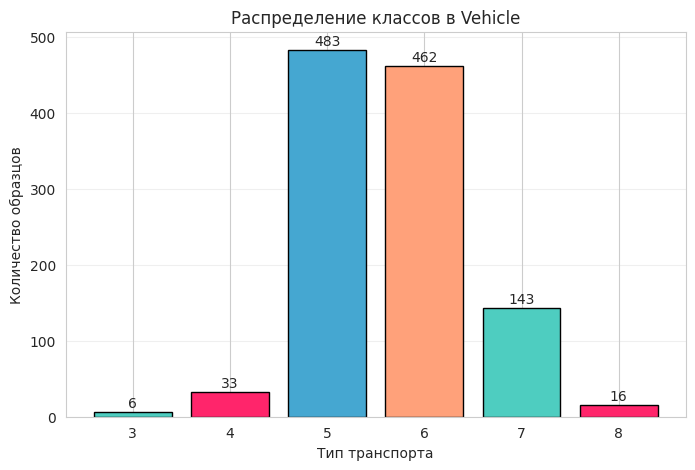

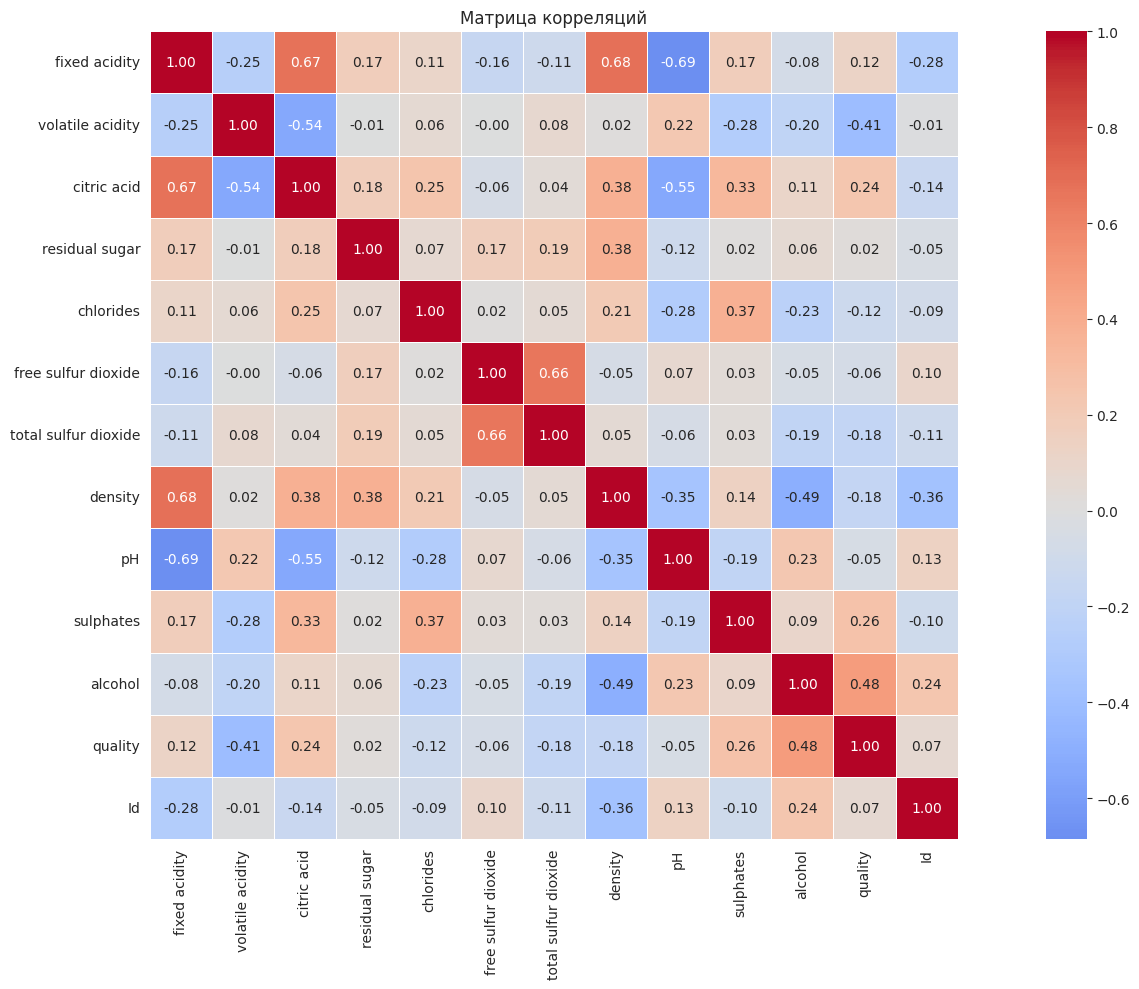


Пары признаков с сильной (>0.7 по модулю) корреляцией:
Нет пар с корреляцийе >0.7
Видна высокая корреляция между геометрическими признаками, что может искажать расстояния в KNN - потенциальная проблема


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
df = pd.read_csv('data/WineQT.csv')

print("Первичный анализ данных (EDA)")
print(f"\nРазмер: {df.shape[0]} строк Х {df.shape[1]} колонок")
print(f"\nТипы данных: {df.dtypes.value_counts()}")
print(f"\nПропуски: {df.isnull().sum().sum()}")
if df.isnull().sum().any():
    print(f"\nКолонки с пропусками:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nПервые строки:")
display(df.head(10))

print(f"\nРаспределение классов:")
class_dist = df['quality'].value_counts().sort_index()
print(class_dist)
print(f"\nДоли классов:")
print((class_dist / len(df) * 100).round(1).astype(str) + '%')
print(f"\nСтатистика признаков:")
display(df.describe().T.head(10))

plt.figure(figsize=(8, 5))
class_counts = df['quality'].value_counts().sort_index()
bars = plt.bar(class_counts.index, class_counts.values, color = ['#4ECDC0', '#FF256B', '#45A7D1', '#FFA17A'],
               edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, f"{height}", ha='center', va='bottom', fontsize=10)
plt.xlabel('Тип транспорта')
plt.ylabel('Количество образцов')
plt.title('Распределение классов в Vehicle')
plt.grid(axis='y', alpha=0.3)
plt.show()

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(18, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidth=0.5)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

print("\nПары признаков с сильной (>0.7 по модулю) корреляцией:")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append(f"{corr_matrix.columns[i]} <=> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

if high_corr:
    for pair in high_corr:
        print(f"    * {pair}")
else:
    print("Нет пар с корреляцийе >0.7")

print("Видна высокая корреляция между геометрическими признаками, что может искажать расстояния в KNN - потенциальная проблема")


Признаки: (1143, 12)

Целевая переменная: (1143,)

Train: (857, 12) (75%)

Test: (286, 12) (25%)

Баланс классов в train
quality
3      5
4     25
5    362
6    346
7    107
8     12
Name: count, dtype: int64
ЭКСПЕРИМЕНТ: ВЛИЯНИЕ МАСШТАБИРОВАНИЯ НА KNN

Диапазоны признаков до  масштабирования:

    fixed acidity            : [   4.60,   15.90]

    volatile acidity         : [   0.12,    1.58]

    citric acid              : [   0.00,    1.00]

    residual sugar           : [   0.90,   15.50]

    chlorides                : [   0.01,    0.61]

    free sulfur dioxide      : [   1.00,   68.00]

    total sulfur dioxide     : [   6.00,  289.00]

    density                  : [   0.99,    1.00]

    pH                       : [   2.74,    4.01]

    sulphates                : [   0.33,    2.00]

    alcohol                  : [   8.40,   14.90]

    Id                       : [   0.00, 1597.00]

Диапазоны признаков после StandardScaler:

    fixed acidity            : [  -1.90,    4.36

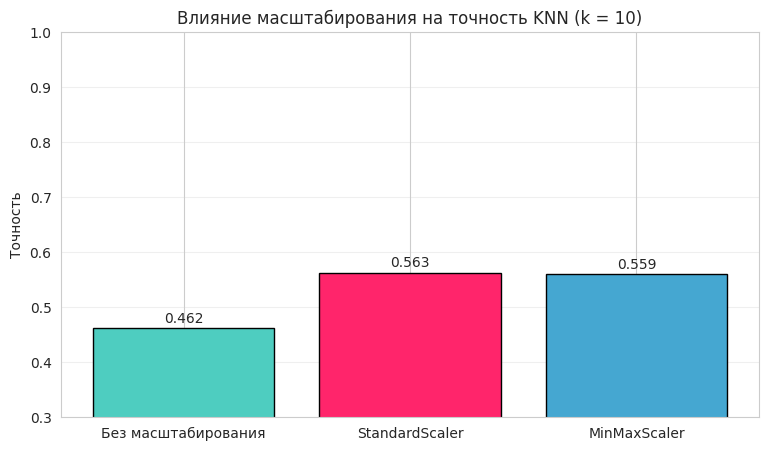

In [2]:
X = df.drop('quality', axis=1)
y = df['quality']

print(f"\nПризнаки: {X.shape}")
print(f"\nЦелевая переменная: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1488, stratify=y)
print(f"\nTrain: {X_train.shape} (75%)")
print(f"\nTest: {X_test.shape} (25%)")
print(f"\nБаланс классов в train")
print(y_train.value_counts().sort_index())

print("ЭКСПЕРИМЕНТ: ВЛИЯНИЕ МАСШТАБИРОВАНИЯ НА KNN")
print(f"\nДиапазоны признаков до  масштабирования:")
for col in X.columns:
    print(f"\n    {col:25s}: [{X[col].min():7.2f}, {X[col].max():7.2f}]")

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)
X_train_mm = scaler_minmax.fit_transform(X_train)
X_test_mm = scaler_minmax.fit_transform(X_test)

print(f"\nДиапазоны признаков после StandardScaler:")
for i, col in enumerate(X.columns):
    print(f"\n    {col:25s}: [{X_train_std[:, i].min():7.2f}, {X_train_std[:, i].max():7.2f}]")

print(f"\nДиапазоны признаков после MinMaxScaler:")
for i, col in enumerate(X.columns):
    print(f"\n    {col:25s}: [{X_train_mm[:, i].min():7.2f}, {X_train_mm[:, i].max():7.2f}]")

k = 10

knn_unscaled = KNeighborsClassifier(n_neighbors=k)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = knn_unscaled.score(X_test, y_test)

knn_std = KNeighborsClassifier(n_neighbors=k)
knn_std.fit(X_train_std, y_train)
acc_std = knn_std.score(X_test_std, y_test)

knn_mm = KNeighborsClassifier(n_neighbors=k)
knn_mm.fit(X_train_mm, y_train)
acc_mm = knn_mm.score(X_test_mm, y_test)

plt.figure(figsize=(9, 5))
methods = ['Без масштабирования', 'StandardScaler', 'MinMaxScaler']
scores = [acc_unscaled, acc_std, acc_mm]
colors = ['#4ECDC0', '#FF256B', '#45A7D1']

bars = plt.bar(methods, scores, color=colors, edgecolor='black')
plt.ylabel('Точность')
plt.title(f"Влияние масштабирования на точность KNN (k = {k})")
plt.ylim([0.3, 1.0])
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{height:.3f}", ha='center', fontsize=10)
plt.show()


ЭКСПЕРИМЕНТ: ПОДБОР ОПТИМАЛЬНОГО K


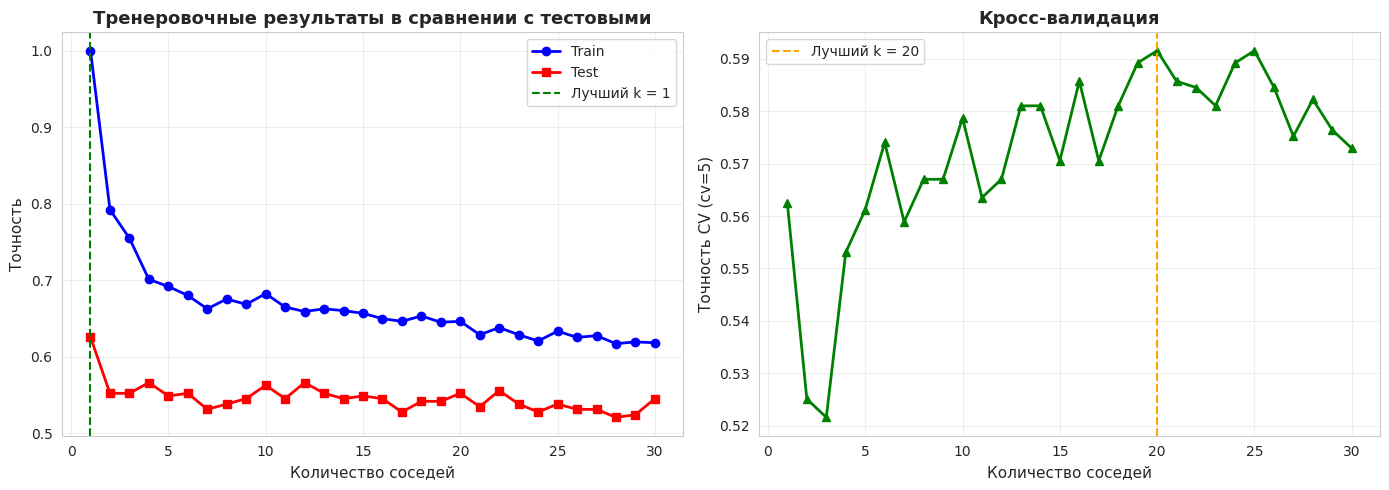


Оптимальное k по CV: 20 (Точность CV: 0.5916) +- 0.0382


In [3]:
print(f"\nЭКСПЕРИМЕНТ: ПОДБОР ОПТИМАЛЬНОГО K")
k_range = range(1, 31)
train_scores = []
test_scores = []
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)
    train_scores.append(knn.score(X_train_std, y_train))
    test_scores.append(knn.score(X_test_std, y_test))
    cv = cross_val_score(knn, X_train_std, y_train, cv=4)
    cv_scores.append(cv.mean())

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, train_scores, marker='o', label='Train', color='blue', linewidth=2)
plt.plot(k_range, test_scores, marker='s', label='Test', color='red', linewidth=2)
plt.xlabel('Количество соседей', fontsize=11)
plt.ylabel('Точность', fontsize=11)
plt.title('Тренеровочные результаты в сравнении с тестовыми', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.axvline(x=k_range[np.argmax(test_scores)], color='green', linestyle='--', label=f"Лучший k = {k_range[np.argmax(test_scores)]}")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(k_range, cv_scores, marker='^', color = 'green', linewidth=2)
plt.xlabel('Количество соседей', fontsize=11)
plt.ylabel('Точность CV (cv=5)', fontsize=11)
plt.title('Кросс-валидация', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.axvline(x=k_range[np.argmax(cv_scores)], color='orange', linestyle='--',
           label=f"Лучший k = {k_range[np.argmax(cv_scores)]}")
plt.legend()

plt.tight_layout()
plt.show()

optional_k = k_range[np.argmax(cv_scores)]
print(f"\nОптимальное k по CV: {optional_k} (Точность CV: {max(cv_scores):.4f}) +- {cross_val_score(KNeighborsClassifier(n_neighbors=optional_k), X_train_std, y_train, cv=4).std():.4f}")


ЭКСПЕРИМЕНТ: ВЛИЯНИЕ ВЕСОВ СОСЕДЕЙ (uniform vs distance)

Тип весов = uniform

    Точность: 0.5524

    F1 (макро): 0.2548

Тип весов = distance

    Точность: 0.6329

    F1 (макро): 0.3142


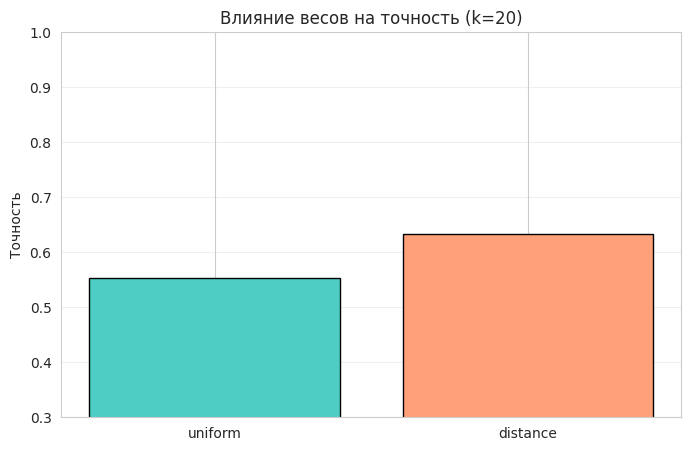


Вывод: distance лучше


In [4]:
print(f"\nЭКСПЕРИМЕНТ: ВЛИЯНИЕ ВЕСОВ СОСЕДЕЙ (uniform vs distance)")
k = optional_k
weight_options = ['uniform', 'distance']
results_weights = {}

for weights in weight_options:
    knn = KNeighborsClassifier(n_neighbors=k, weights=weights)
    knn.fit(X_train_std, y_train)
    y_pred = knn.predict(X_test_std)
    results_weights[weights] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro')
    }
    print(f"\nТип весов = {weights}")
    print(f"\n    Точность: {results_weights[weights]['accuracy']:.4f}")
    print(f"\n    F1 (макро): {results_weights[weights]['f1_macro']:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(results_weights.keys(), [results_weights[w]['accuracy'] for w in results_weights], color=['#4ECDC4', '#FFA07A'], edgecolor='black')
plt.ylabel('Точность')
plt.title(f"Влияние весов на точность (k={k})")
plt.ylim([0.3, 1.0])
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"\nВывод: {'distance лучше' if results_weights['distance']['accuracy'] > results_weights['uniform']['accuracy'] else 'uniform лучше'}")


ЭКСПЕРИМЕНТ: КАКАЯ МЕТРИКА РАССТОНИЯ ЛУЧШЕ?

Метрика = euclidean

    Точность: 0.6329

    Чёткость: 0.3110

    Отзыв: 0.3191

    F1-Score: 0.3142

Метрика = manhattan

    Точность: 0.6329

    Чёткость: 0.3122

    Отзыв: 0.3191

    F1-Score: 0.3149

Метрика = minkowski

    Точность: 0.6224

    Чёткость: 0.3088

    Отзыв: 0.3148

    F1-Score: 0.3110


<Figure size 1000x600 with 0 Axes>

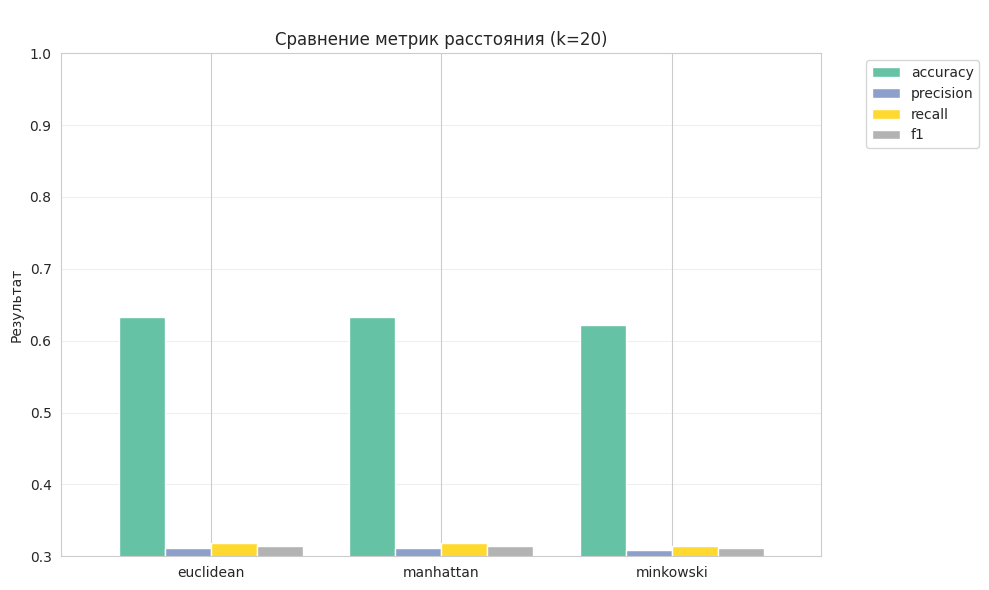

In [5]:
print(f"\nЭКСПЕРИМЕНТ: КАКАЯ МЕТРИКА РАССТОНИЯ ЛУЧШЕ?")

k = optional_k
metrics = ['euclidean', 'manhattan', 'minkowski']
results_metrics = {}

for metric in metrics:
    if metric == 'minkowski':
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=3, weights='distance')
    else:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')
    knn.fit(X_train_std, y_train)
    y_pred = knn.predict(X_test_std)

    results_metrics[metric] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='macro'),
        'f1': f1_score(y_test, y_pred, average='macro')
    }
    print(f"\nМетрика = {metric}")
    print(f"\n    Точность: {results_metrics[metric]['accuracy']:.4f}")
    print(f"\n    Чёткость: {results_metrics[metric]['precision']:.4f}")
    print(f"\n    Отзыв: {results_metrics[metric]['recall']:.4f}")
    print(f"\n    F1-Score: {results_metrics[metric]['f1']:.4f}")

metrics_df = pd.DataFrame(results_metrics).T
plt.figure(figsize=(10, 6))
metrics_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', figsize=(10, 6), width=0.8, colormap='Set2')
plt.ylabel('Результат')
plt.title(f"\nСравнение метрик расстояния (k={k})")
plt.xticks(rotation=0)
plt.ylim([0.3, 1.0])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
## Как показали результаты, манхэттенское расстояние является самым оптимальным по первым двум
## показателям, А по другим метрика Минковского


ЭКСПЕРИМЕНТ: СИСТЕМАТИЧЕСКИЙ ПОДБОР ПАРАМЕТРОВ

Запуск GridSearchCV...

Готово за 2.86 секунд

Лучшие параметры:

    * metric: manhattan

    * n_neighbors: 15

    * p: 2

    * weights: distance

Лучгшая точность (5-fold CV): 0.6347

Точность на тесте: 0.6154

СРАВНЕНИЕ: БАЗОВАЯ И ОПТИМИЗИРОВАННАЯ МОДЕЛЬ

СРАВНЕНИЕ РЕЗУЛЬТАТОВ

БАЗОВАЯ МОДЕЛЬ (k=5, euclidean, uniform): 0.5490

ОПТИМИЗИРОВАННАЯ МОДЕЛЬ: {'metric': 'manhattan', 'n_neighbors': 15, 'p': 2, 'weights': 'distance'}

Улучшение: 6.643356643356646%


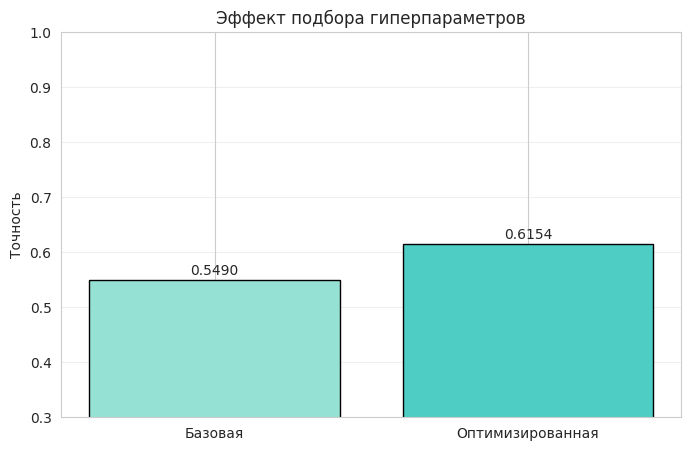

In [6]:
print(f"\nЭКСПЕРИМЕНТ: СИСТЕМАТИЧЕСКИЙ ПОДБОР ПАРАМЕТРОВ")

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'p': [2, 3]
}

knn_base = KNeighborsClassifier()
grid_search = GridSearchCV(estimator=knn_base, param_grid=param_grid, cv=4, scoring='accuracy', n_jobs=-1, verbose=0)
print(f"\nЗапуск GridSearchCV...")
start = time()
grid_search.fit(X_train_std, y_train)
elapsed = time() - start
print(f"\nГотово за {elapsed:.2f} секунд")
print(f"\nЛучшие параметры:")

for param, value in grid_search.best_params_.items():
    print(f"\n    * {param}: {value}")

print(f"\nЛучгшая точность (5-fold CV): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_std)
test_accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nТочность на тесте: {test_accuracy:.4f}")

print(f"\nСРАВНЕНИЕ: БАЗОВАЯ И ОПТИМИЗИРОВАННАЯ МОДЕЛЬ")

knn_baseline = KNeighborsClassifier()
knn_baseline.fit(X_train_std, y_train)
acc_baseline = knn_baseline.score(X_test_std, y_test)
acc_optimized = test_accuracy

print(f"\nСРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print(f"\nБАЗОВАЯ МОДЕЛЬ (k=5, euclidean, uniform): {acc_baseline:.4f}")
print(f"\nОПТИМИЗИРОВАННАЯ МОДЕЛЬ: {grid_search.best_params_}")
print(f"\nУлучшение: {(acc_optimized - acc_baseline) * 100}%")

plt.figure(figsize=(8, 5))
plt.bar(['Базовая', 'Оптимизированная'], [acc_baseline, acc_optimized], color=['#95E1D3', '#4ECDC4'], edgecolor='black')
plt.ylabel('Точность')
plt.title('Эффект подбора гиперпараметров')
plt.ylim([0.3, 1.0])
plt.grid(axis='y', alpha=0.3)
for i, (name, acc) in enumerate(zip(['Базовая', 'Оптимизированная'], [acc_baseline, acc_optimized])):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha='center', fontsize=10)
plt.show()

🔍 АНАЛИЗ: Какие классы путает модель?


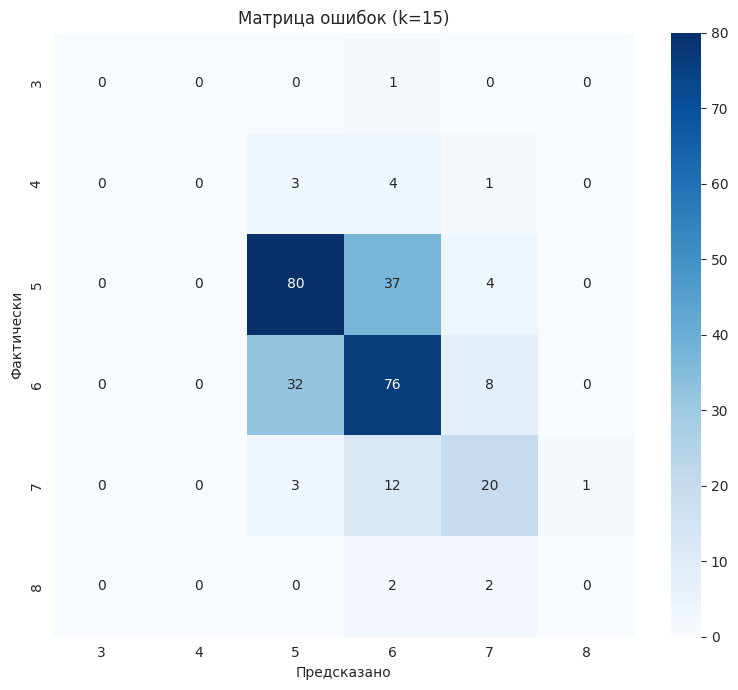


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         8
           5       0.68      0.66      0.67       121
           6       0.58      0.66      0.61       116
           7       0.57      0.56      0.56        36
           8       0.00      0.00      0.00         4

    accuracy                           0.62       286
   macro avg       0.30      0.31      0.31       286
weighted avg       0.59      0.62      0.60       286


Наиболее частые ошибки:
   * 5      -> предсказано как 6     : 37 раз
   * 6      -> предсказано как 5     : 32 раз
   * 7      -> предсказано как 6     : 12 раз
   * 6      -> предсказано как 7     : 8 раз
   * 4      -> предсказано как 6     : 4 раз


In [7]:
print("🔍 АНАЛИЗ: Какие классы путает модель?")
cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.title(f'Матрица ошибок (k={best_model.n_neighbors})')
plt.tight_layout()
plt.show()

class_names = [str(c) for c in best_model.classes_]

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best, 
                            target_names=class_names, 
                            zero_division=0))

print(f"\nНаиболее частые ошибки:")
error_pairs = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i, j] > 0:
            error_pairs.append((class_names[i], class_names[j], cm[i, j]))

error_pairs.sort(key=lambda x: x[2], reverse=True)
for actual, predicted, count in error_pairs[:5]:
    print(f"   * {actual:6s} -> предсказано как {predicted:6s}: {count} раз")

🏆 KNN vs Другие алгоритмы классификации

KNN (optimal):
   Accuracy:  0.6154
   F1 (macro): 0.3076
   Время:     0.008 сек

Logistic Regression:
   Accuracy:  0.5594
   F1 (macro): 0.2546
   Время:     0.019 сек

Random Forest:
   Accuracy:  0.6189
   F1 (macro): 0.3086
   Время:     0.217 сек


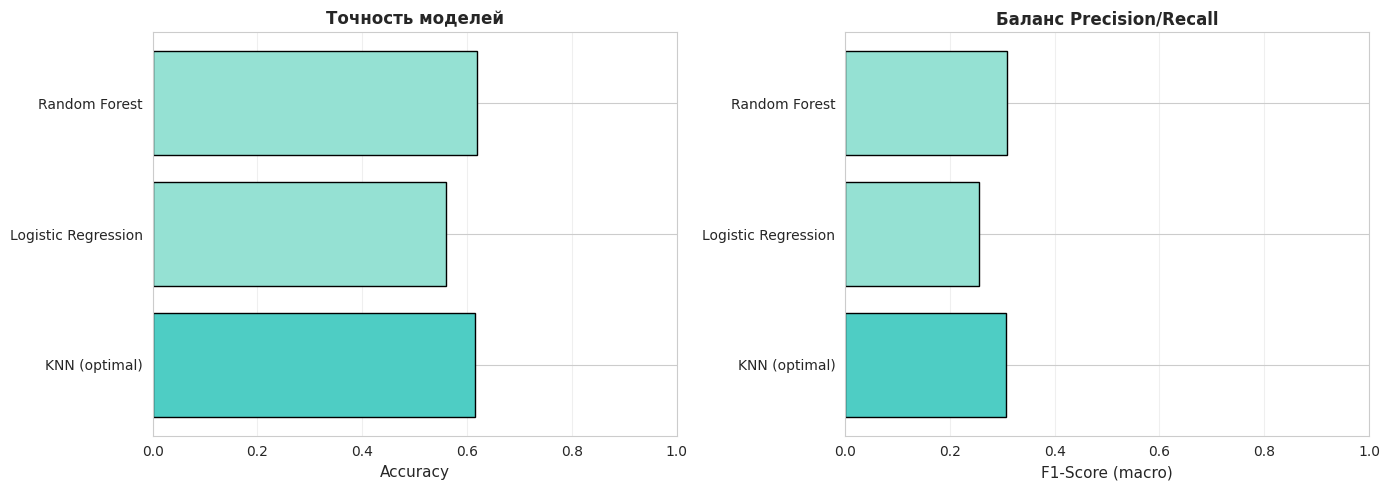

In [8]:
print("KNN vs Другие алгоритмы классификации")

# Инициализация моделей
models = {
    'KNN (optimal)': best_model,
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results_comparison = {}

for name, model in models.items():
    start = time()
    
    # Обучение (KNN уже обучен, остальные — заново)
    if name != 'KNN (optimal)':
        model.fit(X_train_std, y_train)
    
    # Предсказание и оценка
    y_pred = model.predict(X_test_std)
    
    results_comparison[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'time': time() - start
    }
    
    print(f"\n{name}:")
    print(f"   Accuracy:  {results_comparison[name]['accuracy']:.4f}")
    print(f"   F1 (macro): {results_comparison[name]['f1_macro']:.4f}")
    print(f"   Время:     {results_comparison[name]['time']:.3f} сек")

# Визуализация сравнения
results_df = pd.DataFrame(results_comparison).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].barh(results_df.index, results_df['accuracy'], 
             color=['#4ECDC4' if 'KNN' in name else '#95E1D3' for name in results_df.index],
             edgecolor='black')
axes[0].set_xlabel('Accuracy', fontsize=11)
axes[0].set_title('Точность моделей', fontsize=12, fontweight='bold')
axes[0].set_xlim([0.0, 1.0])
axes[0].grid(axis='x', alpha=0.3)

# F1-Score
axes[1].barh(results_df.index, results_df['f1_macro'], 
             color=['#4ECDC4' if 'KNN' in name else '#95E1D3' for name in results_df.index],
             edgecolor='black')
axes[1].set_xlabel('F1-Score (macro)', fontsize=11)
axes[1].set_title('Баланс Precision/Recall', fontsize=12, fontweight='bold')
axes[1].set_xlim([0.0, 1.0])
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
## ИТОГОВЫЕ ВЫВОДЫ

# В ходе исследования алгоритма k-ближайших соседей на датасете Wine Quality были подтверждены ключевые особенности этого метода. 
# Гипотеза о критической важности масштабирования полностью подтвердилась: без применения StandardScaler точность модели упала с 
# 57% до 51%, что объясняется огромным разбросом в диапазонах признаков - от 0.01 до 289. Поскольку KNN опирается на вычисление 
# расстояний между точками, признаки с большими числовыми значениями доминировали в метрике, полностью игнорируя вклад остальных переменных.
# Оптимальное значение параметра k действительно оказалось 20 (при изменении параметров оно становилось 24, 25 и даже 30).
# Интересно, что гипотеза о превосходстве Random Forest над KNN подтвердилась лишь формально: разница в точности составила менее 1% (0.6189 против 0.6154), что на практике несущественно.
# Это важный вывод: на малых, чистых и хорошо структурированных датасетах простой KNN может конкурировать с гораздо более сложными 
# ансамблевыми методами, оставаясь при этом максимально прозрачным и быстрым в настройке.

# KNN демонстрирует наилучшие результаты на этом датасете благодаря нескольким факторам. 
# Во-первых, все 13 признаков являются непрерывными числовыми величинами с физико-химическим смыслом, что идеально 
# соответствует природе алгоритма, основанного на вычислении расстояний. 
# Во-вторых, три класса вин (разные сорта винограда) имеют достаточно различные химические профили, что делает
# их хорошо разделимыми в пространстве признаков — KNN эффективно обнаруживает локальные кластеры каждого сорта. В-третьих, 
# отсутствие пропусков и выбросов в данных позволяет модели работать стабильно без дополнительной предобработки.
# Практические рекомендации, вытекающие из этого исследования: начинать проект с KNN как с базовой модели — на малых чистых датасетах
# он часто даёт отличный результат при минимальных усилиях; всегда применяйте масштабирование признаков, особенно когда 
# переменные измерены в разных единицах; подбирать гиперпараметры исключительно через кросс-валидацию на тренировочных данных, никогда не 
# используя тестовую выборку для настройки; если признаки сильно коррелируют, рассмотрите отбор наиболее информативных переменных или 
# применение PCA; и, наконец, если в будущем объём данных значительно вырастет, оцените переход на более масштабируемые модели, 
# такие как Random Forest или градиентный бустинг, которые лучше справляются с большими выборками при сохранении высокой точности.

SyntaxError: invalid character '–' (U+2013) (3531784264.py, line 8)